<h1 style="text-align:center;">Набор даных для линейных моделей</h1>

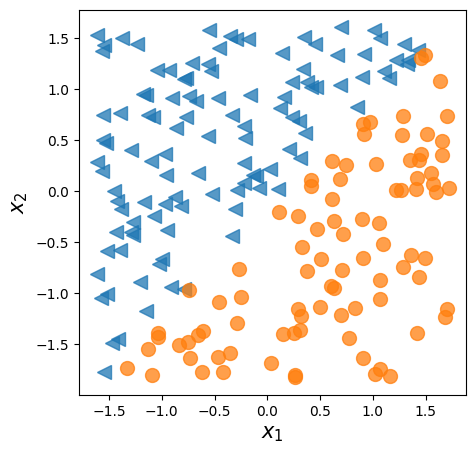

Размер обучающей выборки: 140
Размер тестовой выборки: 60
Распределение классов в train: [62 78]
Распределение классов в test: [27 33]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

# 1. Генерация данных
np.random.seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.where((x[:, 1] - x[:, 0]) >= 0.0, 1, 0)

# Стандартизация признаков
X_std = np.copy(x)
X_std[:, 0] = (x[:, 0] - x[:, 0].mean()) / x[:, 0].std()
X_std[:, 1] = (x[:, 1] - x[:, 1].mean()) / x[:, 1].std()

# 2. Разделение на обучающую (70%) и тестовую (30%) выборки
x_train, x_test, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=42, stratify=y)

fig = plt.figure(figsize=(5, 5))
plt.plot(X_std[y==1, 0], X_std[y==1, 1], '<', alpha=0.75, markersize=10)
plt.plot(X_std[y==0, 0], X_std[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

print(f"Размер обучающей выборки: {x_train.shape[0]}")
print(f"Размер тестовой выборки: {x_test.shape[0]}")
print(f"Распределение классов в train: {np.bincount(y_train)}")
print(f"Распределение классов в test: {np.bincount(y_test)}")

<h1 style="text-align:center;">Персептрон МСР</h1>


 Эпоха   | Точность (train) | Потери (train)  | Точность (test) |  Потери (test) 
   1     |     0.8714      |     0.1286      |     0.9000      |     0.1000     
   2     |     0.9643      |     0.0357      |     0.9167      |     0.0833     
   3     |     0.9214      |     0.0786      |     0.9333      |     0.0667     
   4     |     0.9500      |     0.0500      |     1.0000      |     0.0000     
   5     |     0.9857      |     0.0143      |     1.0000      |     0.0000     

Финальная точность на обучающей выборке: 0.9929
Финальная точность на тестовой выборке: 1.0000
Веса: w = [-0.53168259  0.49771906], b = 0.1000


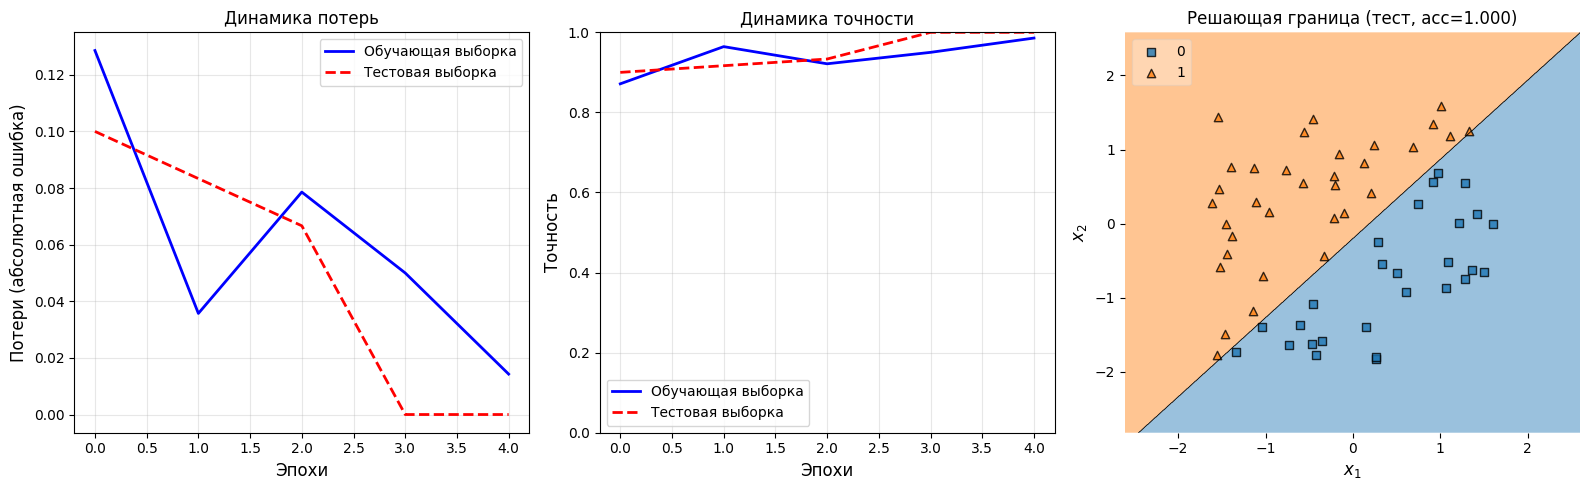

In [2]:
class Perceptron:
    def __init__(self, eta=0.1, num_epochs=50, random_state=1, verbose=True):
        self.eta = eta                    
        self.num_epochs = num_epochs      
        self.random_state = random_state  
        self.verbose = verbose            

    def fit(self, X, y, X_test=None, y_test=None):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)

        self.loss_hist_train = []
        self.accuracy_hist_train = []
        self.loss_hist_test = []
        self.accuracy_hist_test = []

        if self.verbose:
            print("\n" + "="*80)
            print(f"{'Эпоха':^8} | {'Точность (train)':^15} | {'Потери (train)':^15} | {'Точность (test)':^15} | {'Потери (test)':^15}")
            print("="*80)

        for epoch in range(self.num_epochs):
            epoch_loss = 0
            epoch_correct = 0
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                loss = target - prediction
                update = self.eta * loss
                self.w_ += update * xi
                self.b_ += update
                epoch_loss += abs(loss) 
                epoch_correct += (prediction == target)
            
            train_loss = epoch_loss / len(X)
            train_accuracy = epoch_correct / len(X)
            self.loss_hist_train.append(train_loss)
            self.accuracy_hist_train.append(train_accuracy)
            
            if X_test is not None and y_test is not None:
                test_predictions = self.predict(X_test)
                test_errors = y_test - test_predictions
                test_loss = np.mean(np.abs(test_errors))
                test_accuracy = np.mean(test_predictions == y_test)
                self.loss_hist_test.append(test_loss)
                self.accuracy_hist_test.append(test_accuracy)
                
                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {train_loss:^15.4f} | {test_accuracy:^15.4f} | {test_loss:^15.4f}")
            else:
                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {train_loss:^15.4f} | {'N/A':^15} | {'N/A':^15}")
        
        if self.verbose:
            print("="*80 + "\n")
        
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)
    
    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)
######################################################################
ppn = Perceptron(eta=0.1, num_epochs=5, random_state=1)
ppn.fit(x_train, y_train, x_test, y_test)
######################################################################
train_accuracy = ppn.score(x_train, y_train)
test_accuracy = ppn.score(x_test, y_test)

print(f"Финальная точность на обучающей выборке: {train_accuracy:.4f}")
print(f"Финальная точность на тестовой выборке: {test_accuracy:.4f}")
print(f"Веса: w = {ppn.w_}, b = {ppn.b_:.4f}")

fig = plt.figure(figsize=(16, 5))
# График 1: Потери
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(ppn.loss_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn.loss_hist_test:
    ax1.plot(ppn.loss_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax1.set_xlabel('Эпохи', size=12)
ax1.set_ylabel('Потери (абсолютная ошибка)', size=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Динамика потерь', fontsize=12)
# График 2: Точность
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(ppn.accuracy_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn.accuracy_hist_test:
    ax2.plot(ppn.accuracy_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax2.set_xlabel('Эпохи', size=12)
ax2.set_ylabel('Точность', size=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])
ax2.set_title('Динамика точности', size=12)
# График 3: Решающая граница на тестовых данных
ax3 = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_test, 
                      y=y_test,
                      clf=ppn,
                      legend=2)
ax3.set_xlabel(r'$x_1$', size=12)
ax3.set_ylabel(r'$x_2$', size=12)
ax3.set_title(f'Решающая граница (тест, acc={test_accuracy:.3f})', size=12)
plt.tight_layout()
plt.show()

Правило обучения:
1. Инициализируем компоненты веса и смещения нулями или небольшими случайными числами.
2. Для каждого обучающего образцах ($x^{(i)}$):\
• Вычисляем выходное значение $\hat{y}^{(i)} = z = w_1*x_1 + ... + w_m*x_m + b = w^T*x + b$.\
• Обновляем компоненты веса и смещения.\
Здесь выходным значением является метка класса, предсказанная единичной ступенчатой функцией, а одновременное обновление смещения
и каждого веса $w_j$ в векторе весов $w$ можно записать как:\
$w_j := w_j + \Delta w_j$\
$b := b + \Delta b$\
Значения обновления («дельты») вычисляются следующим образом:\
$\Delta w_j = n(y^{(i)} - \hat{y}^{(i)})x^{(i)}_j$\
$\Delta b = n(y^{(i)} - \hat{y}^{(i)})$

<h1 style="text-align:center;">1.Адаптивные линейные нейроны (Adaline) ALN</h1>
<h1 style="text-align:center;">1.1 Полный пакетный градиентный спуск</h1>


 Эпоха   | Точность (train) | Потери (train)  | Точность (test) |  Потери (test) 
   1     |     0.4429      |     0.5697      |     0.4500      |     0.3958     
   2     |     0.4429      |     0.3946      |     0.4500      |     0.2873     
   3     |     0.4500      |     0.2825      |     0.5667      |     0.2165     
   4     |     0.5857      |     0.2106      |     0.6833      |     0.1701     
   5     |     0.6786      |     0.1645      |     0.8000      |     0.1397     
   6     |     0.7786      |     0.1348      |     0.8333      |     0.1195     
   7     |     0.8357      |     0.1158      |     0.8500      |     0.1062     
   8     |     0.8786      |     0.1036      |     0.9000      |     0.0973     
   9     |     0.9143      |     0.0957      |     0.9167      |     0.0913     
   10    |     0.9357      |     0.0906      |     0.9167      |     0.0873     
   11    |     0.9357      |     0.0873      |     0.9167      |     0.0845     
   12    |     0.9714     

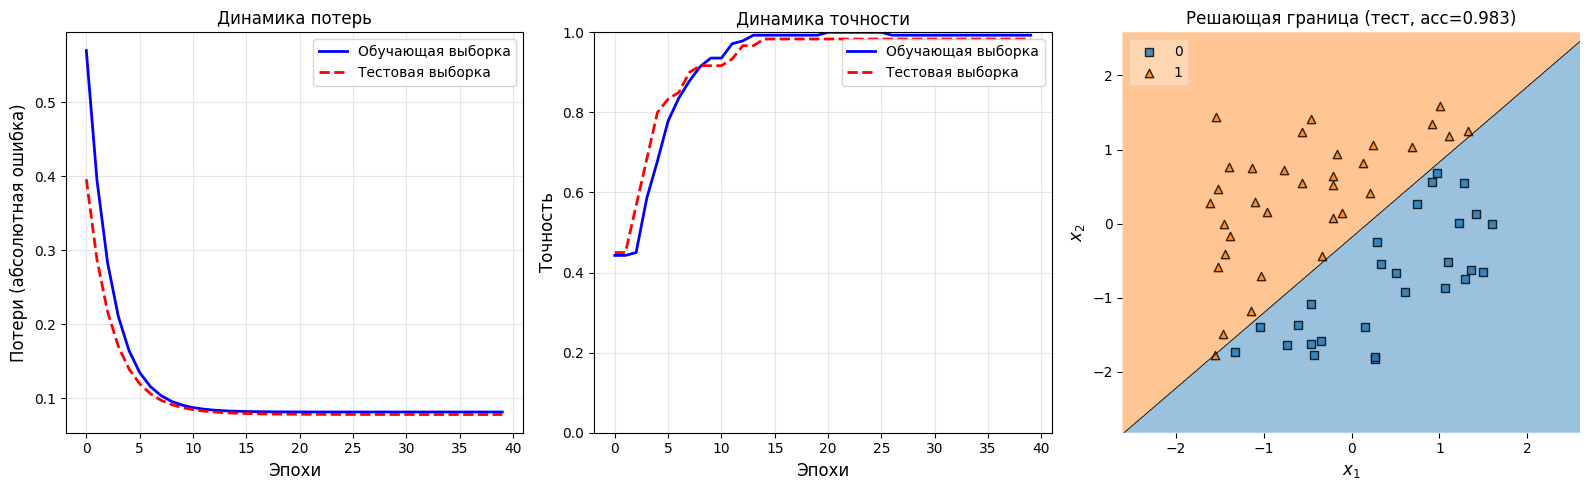

In [3]:
class AdalineGD:
    def __init__(self, eta=0.1, num_epochs=50, random_state=1, verbose=True):
        self.eta = eta                    
        self.num_epochs = num_epochs      
        self.random_state = random_state  
        self.verbose = verbose

    def fit(self, X, y, X_test=None, y_test=None):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)

        self.loss_hist_train = []     
        self.accuracy_hist_train = [] 
        self.loss_hist_test = []
        self.accuracy_hist_test = []

        if self.verbose:
            print("\n" + "="*80)
            print(f"{'Эпоха':^8} | {'Точность (train)':^15} | {'Потери (train)':^15} | {'Точность (test)':^15} | {'Потери (test)':^15}")
            print("="*80)

        for epoch in range(self.num_epochs):
            net_input = self.net_input(X)
            train_loss = ((y - net_input) ** 2).mean()
            train_accuracy = np.mean((net_input >= 0.5) == y)
            self.loss_hist_train.append(train_loss)
            self.accuracy_hist_train.append(train_accuracy)
            output = self.activation(net_input)
            errors = y - output
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()      

            if X_test is not None and y_test is not None:
                test_net_input = self.net_input(X_test)
                test_predictions = np.where(test_net_input >= 0.5, 1, 0)
                test_errors = y_test - test_net_input
                test_loss = (test_errors ** 2).mean()
                test_accuracy = np.mean(test_predictions == y_test)
                self.loss_hist_test.append(test_loss)
                self.accuracy_hist_test.append(test_accuracy)

                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {train_loss:^15.4f} | {test_accuracy:^15.4f} | {test_loss:^15.4f}")
            else:
                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {train_loss:^15.4f} | {'N/A':^15} | {'N/A':^15}")
        
        if self.verbose:
            print("="*80 + "\n")

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        return X

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.5, 1, 0)

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)
######################################################################
ppn1 = AdalineGD(eta=0.1, num_epochs=40, random_state=1)
ppn1.fit(x_train, y_train, x_test, y_test)
######################################################################
train_accuracy = ppn1.score(x_train, y_train)
test_accuracy = ppn1.score(x_test, y_test)

print(f"Финальная точность на обучающей выборке: {train_accuracy:.4f}")
print(f"Финальная точность на тестовой выборке: {test_accuracy:.4f}")
print(f"Веса: w = {ppn1.w_}, b = {ppn1.b_:.4f}")

fig = plt.figure(figsize=(16, 5))
# График 1: Потери
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(ppn1.loss_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn1.loss_hist_test:
    ax1.plot(ppn1.loss_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax1.set_xlabel('Эпохи', size=12)
ax1.set_ylabel('Потери (абсолютная ошибка)', size=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Динамика потерь', fontsize=12)
# График 2: Точность
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(ppn1.accuracy_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn1.accuracy_hist_test:
    ax2.plot(ppn1.accuracy_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax2.set_xlabel('Эпохи', size=12)
ax2.set_ylabel('Точность', size=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])
ax2.set_title('Динамика точности', size=12)
# График 3: Решающая граница на тестовых данных
ax3 = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_test, 
                      y=y_test,
                      clf=ppn1,
                      legend=2)
ax3.set_xlabel(r'$x_1$', size=12)
ax3.set_ylabel(r'$x_2$', size=12)
ax3.set_title(f'Решающая граница (тест, acc={test_accuracy:.3f})', size=12)
plt.tight_layout()
plt.show()

Правило обучения:

В случае Adaline определяем функцию потерь L как среднеквадратичную ошибку (Mean Squared Error,MSE) между вычисленным выходным значением и истинной меткой класса: $L(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \sigma (\hat{y}^{(i)}))^2$, где $\sigma (\hat{y}^{(i)})$ - это функция активации (в данном примере эта функция не имеет никакого эффекта в коде, поскольку это просто функция идентификации $f(y) = x$).

Поскольку функция потерь L выпуклая, - мы можем используем алгоритм оптимизации, называемый градиентным спуском (gradient descent), чтобы найти веса, которые минимизируют нашу функцию потерь.

Используя градиентный спуск, мы обновляем параметры модели, делая шаг в направлении, противоположном градиенту $\nabla L(w, b)$ нашей функции потерь $L(w, b)$:

$w := w + \Delta w$\
$b := b + \Delta b$\
где $\Delta w = -n \nabla_w L(w, b)$, $\Delta b =  -n \nabla_b L(w, b)$.

Чтобы получить градиент функции потерь, нам нужно вычислить:

а) частную производную функции потерь по каждому весу $w_j$: $\frac{\partial L}{\partial w_j} = -\frac{2}{n} \sum_{j} (y^{(i)} - \sigma (\hat{y}^{(i)}))x^{(i)}_j$

б) частную производную потерь по смещению:  $\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{j} (y^{(i)} - \sigma (\hat{y}^{(i)}))$

1. Инициализируем компоненты веса и смещения нулями или небольшими случайными числами.
2. Для всего обучающего набора данных:\
• Вычисляем выходные значения $\hat{y} = z = w^T*x + b$.\
• Находим выход функции активации от аргумента ввиде вычисленных выходных значениях $\sigma (\hat{y}^{(i)}) = x$.\
• Вычисляем ошибку $error = y^{(i)} - \sigma (\hat{y}^{(i)})$\
• Обновляем компоненты веса и смещения на основе вычеслинного градиента по всему обучающему набору данных.

$w := w + \Delta w$\
$b := b + \Delta b$

<h1 style="text-align:center;">1.2 Стохастический градиентный спуск SGD</h1>


 Эпоха   | Точность (train) | Потери (train)  | Точность (test) |  Потери (test) 
   1     |     0.8571      |     0.2511      |     0.8333      |     0.1134     
   2     |     0.9714      |     0.0935      |     0.9333      |     0.0815     
   3     |     0.9786      |     0.0841      |     0.9833      |     0.0784     
   4     |     0.9857      |     0.0836      |     0.9833      |     0.0779     
   5     |     0.9857      |     0.0835      |     0.9833      |     0.0778     
   6     |     0.9857      |     0.0835      |     0.9833      |     0.0778     
   7     |     0.9857      |     0.0835      |     0.9833      |     0.0778     
   8     |     0.9857      |     0.0835      |     0.9833      |     0.0778     
   9     |     0.9857      |     0.0835      |     0.9833      |     0.0778     
   10    |     0.9857      |     0.0835      |     0.9833      |     0.0778     

Финальная точность на обучающей выборке: 0.9857
Финальная точность на тестовой выборке: 0.9833
Веса: w = [

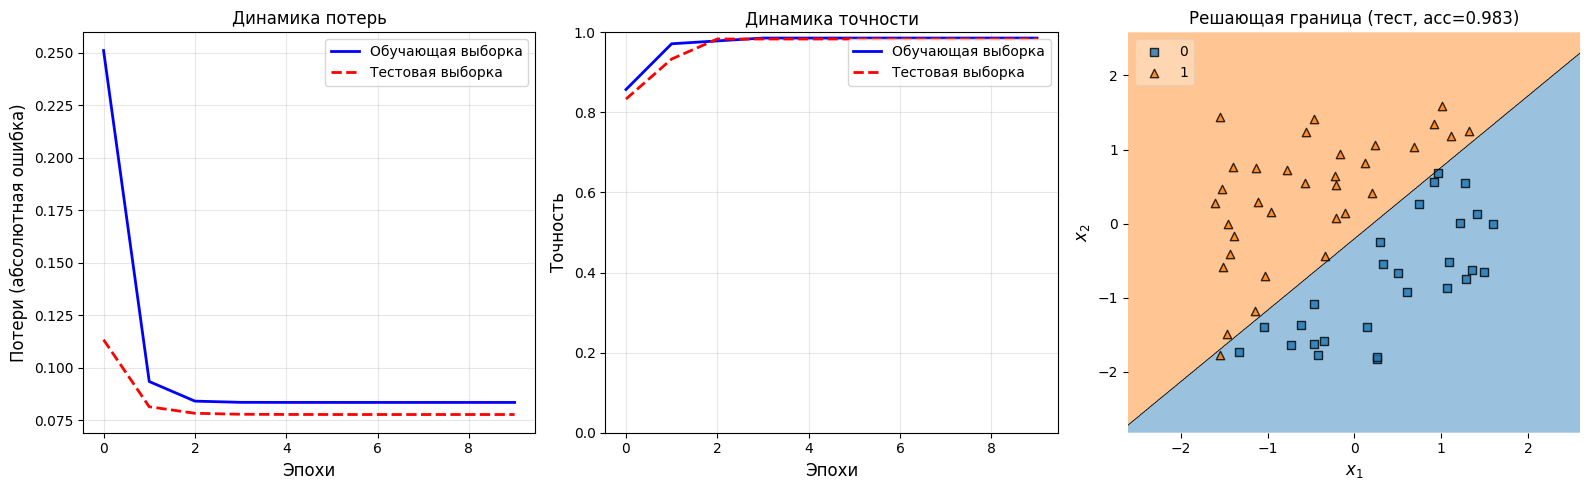

In [4]:
class AdalineSGD:
    def __init__(self, eta=0.01, num_epochs=10, shuffle=True, random_state=1, verbose=True):
        self.eta = eta                    
        self.num_epochs = num_epochs      
        self.shuffle = shuffle            
        self.random_state = random_state  
        self.verbose = verbose
        self.w_initialized = False

    def _initialize_weights(self, m):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True

    def _shuffle(self, X, y):
        r = np.random.RandomState(self.random_state).permutation(len(y))
        return X[r], y[r]

    def _update_weights(self, xi, target):
        output = self.activation(self.net_input(xi))
        error = target - output
        self.w_ += self.eta * 2.0 * xi * error
        self.b_ += self.eta * 2.0 * error
        loss = error ** 2
        return loss

    def fit(self, X, y, X_test=None, y_test=None):
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])

        self.loss_hist_train = []     
        self.accuracy_hist_train = [] 
        self.loss_hist_test = []
        self.accuracy_hist_test = []

        if self.verbose:
            print("\n" + "="*80)
            print(f"{'Эпоха':^8} | {'Точность (train)':^15} | {'Потери (train)':^15} | {'Точность (test)':^15} | {'Потери (test)':^15}")
            print("="*80)

        for epoch in range(self.num_epochs):
            if self.shuffle:
                X_shuffled, y_shuffled = self._shuffle(X, y)
            else:
                X_shuffled, y_shuffled = X, y

            epoch_losses = []
            for xi, target in zip(X_shuffled, y_shuffled):
                loss = self._update_weights(xi, target)
                epoch_losses.append(loss)

            avg_train_loss = np.mean(epoch_losses)
            train_predictions = self.predict(X)
            train_accuracy = np.mean(train_predictions == y)
            self.loss_hist_train.append(avg_train_loss)
            self.accuracy_hist_train.append(train_accuracy)

            if X_test is not None and y_test is not None:
                test_predictions = self.predict(X_test)
                test_accuracy = np.mean(test_predictions == y_test)
                
                test_net_input = self.net_input(X_test)
                test_errors = y_test - test_net_input
                test_loss = (test_errors ** 2).mean()
                self.loss_hist_test.append(test_loss)
                self.accuracy_hist_test.append(test_accuracy)

                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {avg_train_loss:^15.4f} | {test_accuracy:^15.4f} | {test_loss:^15.4f}")
            else:
                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {avg_train_loss:^15.4f} | {'N/A':^15} | {'N/A':^15}")
        
        if self.verbose:
            print("="*80 + "\n")
        return self

    def partial_fit(self, X, y):
        if not self.w_initialized:
            self._initialize_weights(X.shape[1] if X.ndim > 1 else 1)
        if y.ndim > 0 and len(y) > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        return X

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.5, 1, 0)

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

######################################################################
ppn2 = AdalineSGD(eta=0.005, num_epochs=10, random_state=1)
ppn2.fit(x_train, y_train, x_test, y_test)
######################################################################
train_accuracy = ppn2.score(x_train, y_train)
test_accuracy = ppn2.score(x_test, y_test)

print(f"Финальная точность на обучающей выборке: {train_accuracy:.4f}")
print(f"Финальная точность на тестовой выборке: {test_accuracy:.4f}")
print(f"Веса: w = {ppn2.w_}, b = {ppn2.b_:.4f}")

fig = plt.figure(figsize=(16, 5))
# График 1: Потери
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(ppn2.loss_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn2.loss_hist_test:
    ax1.plot(ppn2.loss_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax1.set_xlabel('Эпохи', size=12)
ax1.set_ylabel('Потери (абсолютная ошибка)', size=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Динамика потерь', fontsize=12)
# График 2: Точность
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(ppn2.accuracy_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn2.accuracy_hist_test:
    ax2.plot(ppn2.accuracy_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax2.set_xlabel('Эпохи', size=12)
ax2.set_ylabel('Точность', size=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])
ax2.set_title('Динамика точности', size=12)
# График 3: Решающая граница на тестовых данных
ax3 = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_test, 
                      y=y_test,
                      clf=ppn2,
                      legend=2)
ax3.set_xlabel(r'$x_1$', size=12)
ax3.set_ylabel(r'$x_2$', size=12)
ax3.set_title(f'Решающая граница (тест, acc={test_accuracy:.3f})', size=12)
plt.tight_layout()
plt.show()

Правило обучения:

В случае SGD вместо обновления весов исходя из суммы накопленных ошибок по всем обучающим образцам мы пошагово обновляем параметры для каждого обучающего примера - например:\
вместо $\Delta w = -n -\frac{2}{n} \sum_{j} (y^{(i)} - \sigma (\hat{y}^{(i)}))x^{(i)}_j$, так: $\Delta w = -n (y^{(i)} - \sigma (\hat{y}^{(i)}))x^{(i)}_j$\
вместо $\Delta b =  -n -\frac{2}{n} \sum_{j} (y^{(i)} - \sigma (\hat{y}^{(i)})))$, так $\Delta b =  -n (y^{(i)} - \sigma (\hat{y}^{(i)}))),$\
где $\sigma (\hat{y}^{(i)})$ - это функция активации (в данном примере эта функция не имеет никакого эффекта в коде, поскольку это просто функция идентификации $f(y) = x$).

1. Инициализируем компоненты веса и смещения нулями или небольшими случайными числами.
2. Для каждого обучающего примера:\
• Вычисляем выходное значение $\hat{y} = z = w^T*x + b$.\
• Находим выход функции активации от аргумента ввиде вычисленного выходного значения $\sigma (\hat{y}^{(i)}) = x$.\
• Вычисляем ошибку $error = y^{(i)} - \sigma (\hat{y}^{(i)})$\
• Обновляем компоненты веса и смещения на основе вычеслинного градиента по каждому обучающему примеру

<h1 style="text-align:center;">Логистическая регрессия</h1>


 Эпоха   | Точность (train) | Потери (train)  | Точность (test) |  Потери (test) 
   1     |     0.1643      |     0.6995      |     0.9167      |     0.6689     
   2     |     0.9571      |     0.6671      |     0.9833      |     0.6415     
   3     |     0.9714      |     0.6378      |     0.9833      |     0.6166     
   4     |     0.9786      |     0.6112      |     0.9833      |     0.5939     
   5     |     0.9857      |     0.5870      |     0.9833      |     0.5731     
   6     |     0.9857      |     0.5651      |     0.9833      |     0.5540     
   7     |     0.9857      |     0.5450      |     0.9833      |     0.5365     
   8     |     0.9857      |     0.5267      |     0.9833      |     0.5204     
   9     |     0.9857      |     0.5100      |     0.9833      |     0.5056     
   10    |     0.9857      |     0.4946      |     0.9833      |     0.4918     
   11    |     0.9857      |     0.4804      |     0.9833      |     0.4791     
   12    |     0.9857     

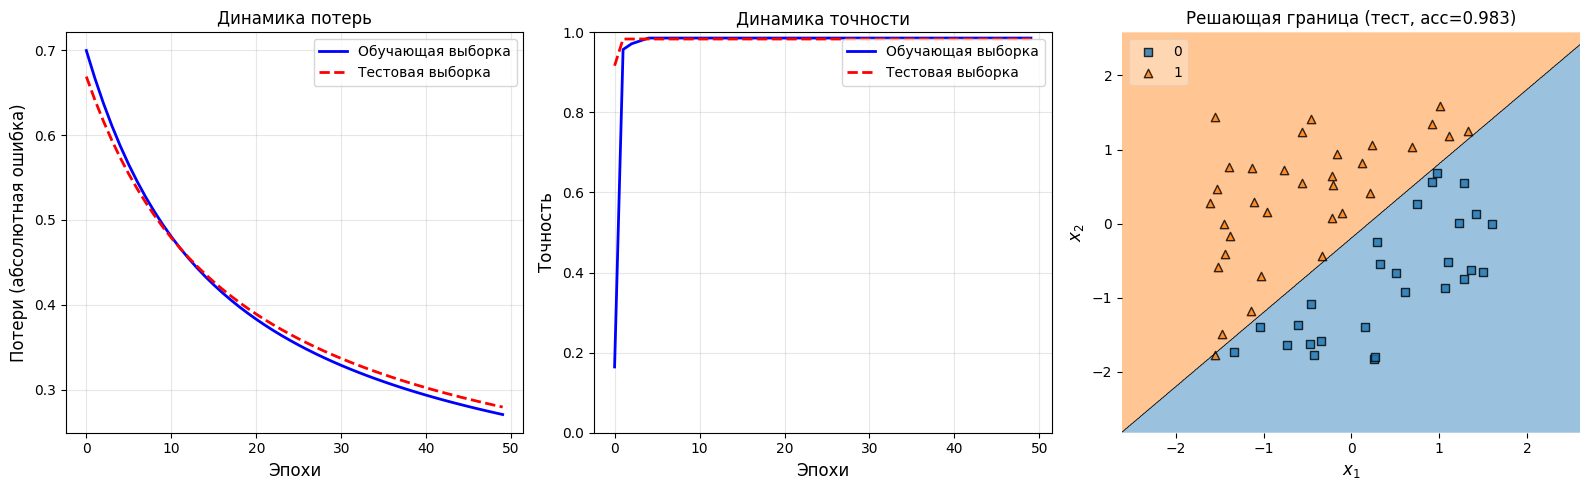

In [5]:
class LogisticRegressionGD:
    def __init__(self, eta=0.1, num_epochs=80, random_state=1, verbose=True):
        self.eta = eta                    
        self.num_epochs = num_epochs      
        self.random_state = random_state  
        self.verbose = verbose

    def fit(self, X, y, X_test=None, y_test=None):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)

        self.loss_hist_train = []     
        self.accuracy_hist_train = [] 
        self.loss_hist_test = []
        self.accuracy_hist_test = []

        if self.verbose:
            print("\n" + "="*80)
            print(f"{'Эпоха':^8} | {'Точность (train)':^15} | {'Потери (train)':^15} | {'Точность (test)':^15} | {'Потери (test)':^15}")
            print("="*80)

        for epoch in range(self.num_epochs):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            train_loss = (-y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output))) / X.shape[0]
            train_accuracy = np.mean((output >= 0.5) == y)
            self.loss_hist_train.append(train_loss)
            self.accuracy_hist_train.append(train_accuracy)

            errors = y - output
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()      

            if X_test is not None and y_test is not None:
                test_net_input = self.activation(self.net_input(X_test))
                test_loss = (-y_test.dot(np.log(test_net_input)) - (1 - y_test).dot(np.log(1 - test_net_input))) / X_test.shape[0]
                test_accuracy = np.mean((test_net_input >= 0.5) == y_test)
                self.loss_hist_test.append(test_loss)
                self.accuracy_hist_test.append(test_accuracy)

                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {train_loss:^15.4f} | {test_accuracy:^15.4f} | {test_loss:^15.4f}")
            else:
                if self.verbose:
                    print(f"{epoch+1:^8} | {train_accuracy:^15.4f} | {train_loss:^15.4f} | {'N/A':^15} | {'N/A':^15}")
        
        if self.verbose:
            print("="*80 + "\n")

        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        """Вычисление логистической сигмоидной активации"""
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
         return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)
######################################################################
ppn3 = LogisticRegressionGD(eta=0.1, num_epochs=50, random_state=1)
ppn3.fit(x_train, y_train, x_test, y_test)
######################################################################
train_accuracy = ppn3.score(x_train, y_train)
test_accuracy = ppn3.score(x_test, y_test)

print(f"Финальная точность на обучающей выборке: {train_accuracy:.4f}")
print(f"Финальная точность на тестовой выборке: {test_accuracy:.4f}")
print(f"Веса: w = {ppn3.w_}, b = {ppn3.b_:.4f}")

fig = plt.figure(figsize=(16, 5))
# График 1: Потери
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(ppn3.loss_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn3.loss_hist_test:
    ax1.plot(ppn3.loss_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax1.set_xlabel('Эпохи', size=12)
ax1.set_ylabel('Потери (абсолютная ошибка)', size=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Динамика потерь', fontsize=12)
# График 2: Точность
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(ppn3.accuracy_hist_train, 'b-', lw=2, label='Обучающая выборка')
if ppn3.accuracy_hist_test:
    ax2.plot(ppn3.accuracy_hist_test, 'r--', lw=2, label='Тестовая выборка')
ax2.set_xlabel('Эпохи', size=12)
ax2.set_ylabel('Точность', size=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])
ax2.set_title('Динамика точности', size=12)
# График 3: Решающая граница на тестовых данных
ax3 = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_test, 
                      y=y_test,
                      clf=ppn3,
                      legend=2)
ax3.set_xlabel(r'$x_1$', size=12)
ax3.set_ylabel(r'$x_2$', size=12)
ax3.set_title(f'Решающая граница (тест, acc={test_accuracy:.3f})', size=12)
plt.tight_layout()
plt.show()

Правило обучения:

В случае Логистической регресии мы не вычисляем функцию потерь L как среднеквадратичную ошибку (Mean Squared Error,MSE) и пытаемся её минимизировать. Вместо этого мы вычисляем функцию правдоподобия и максимизируем её. 

Для этого мы определяем шанс определенного события(предсказание верно) как $\frac{p}{1-p}$, где p - вероятность события
Затем мы можем дополнительно определить логuт-функцию - математическое преобразование, которое переводит вероятность события в логарифм шансов:\
$logit(p) = ln(\frac{p}{1 - p})$, для (0 < p < 1), при этом logit(log-odds) от -∞ до +∞

В рамках лоrистической модели мы предполагаем, что существует линейная зависимость между взвешенными входными данными (фактическими входными данными z) и логuт-функцией: logit(p) = $\sum z$ = $w.T * xi +b$. Нас интересует р - вероятность принадлежности образца к определенному классу при заданных признаках. Поскольку лоrит-функция отображает вероятность в диапазон действительных чисел, мы можем взять обратную функцию, чтобы отобразить диапазон действительных чисел
обратно - в диапазон [0, 1] для вероятности р.

Если $z = logit(p) = ln(\frac{p}{1-p})$, то обратное преобразование (из логита обратно в вероятность) даётся логистической функцией: \ 
$p = σ(z) = \frac{1}{(1 + e^{-z})}$ - сигмоида, где $z =  w.T * xi +b$. Данная сигмоида и будет нашей функцией активации для определения вероятности принадлежности к классу по значению фактического фхода.

Поскольку нам дана задача двоичной классификации с метками классов 0 и 1, то $P(Y=1|X=x_i) = p$, $P(Y=0|X=x_i) = 1 - p$, где p — вероятность принадлежности к определённому классу (0 ≤ p ≤ 1). Данная запись соответствует распределению Бернулли и одной форулой будет выглядеть как:\
$P(Y=y_i|X=x_i) = P(y_i|x_i) = (p^{y_i})*(1-p)^{(1-y_i)}, y_i ∈ {0,1}$. Как мы выяснили ранее p = σ(z):\
$P(y_i|x_i) = (σ(z)^{y_i})*(1-σ(z))^{(1-y_i)}$

Для независимых наблюдений, правдоподобие параметров модели L(w,b|x) = $\prod_{i}P(yi|xi).$ Но на практике проще логарифмировать это уравнения и произведение заменится на сложение натуральных догорифмов (функция логарифмического правдоподобия):\
$ln(L(w,b|x)) = \sum_{i}(y_i*ln(σ(z_i)) + (1-y_i)*ln(1-σ(z_i)))$

У нас получилась функция логарифмического правдоподобия, которую нам надо максимирировать (градиентный подъем), но чтобы использовать градиентный спуск как в примерах выше и поличить похожие графики умножим правую часть уравнения на -1:\
$ln(L(w,b|x)) = \sum_{i}(-y_i*ln(σ(z_i)) - (1-y_i)*ln(1-σ(z_i)))$

____________________________________________________________________________________________________________________________________
Поскольку функция потерь L выпуклая, - мы можем используем алгоритм оптимизации, называемый градиентным спуском (gradient descent), чтобы найти веса, которые минимизируют нашу функцию потерь.

Используя градиентный спуск, мы обновляем параметры модели, делая шаг в направлении, противоположном градиенту $\nabla L(w, b)$ нашей функции потерь $L(w, b)$:

$w := w + \Delta w$\
$b := b + \Delta b$\
где $\Delta w = -n \nabla_w L(w, b)$, $\Delta b =  -n \nabla_b L(w, b)$.

Чтобы получить градиент функции потерь, нам нужно вычислить:

а) частную производную функции потерь по каждому весу $w_j$: $\frac{\partial L}{\partial w_j} = -\frac{2}{n} \sum_{j} (y^{(i)} - \sigma (\hat{y}^{(i)}))x^{(i)}_j$

б) частную производную потерь по смещению:  $\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{j} (y^{(i)} - \sigma (\hat{y}^{(i)}))$

1. Инициализируем компоненты веса и смещения нулями или небольшими случайными числами.
2. Для всего обучающего набора данных:\
• Вычисляем выходные значения $\hat{y} = z = w^T*x + b$.\
• Находим выход функции активации от аргумента ввиде вычисленных выходных значениях $\sigma (\hat{y}^{(i)}) = x$.\
• Вычисляем ошибку $error = y^{(i)} - \sigma (\hat{y}^{(i)})$\
• Обновляем компоненты веса и смещения на основе вычеслинного градиента по всему обучающему набору данных.

$w := w + \Delta w$\
$b := b + \Delta b$

<h1 style="text-align:center;">PyTorch</h1>

In [ ]:
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
x_valid_t = torch.tensor(x_test, dtype=torch.float32)
y_valid_t = torch.tensor(y_test, dtype=torch.float32)

model = nn.Sequential(nn.Linear(2, 1),nn.Sigmoid())
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


train_ds = TensorDataset(x_train_t, y_train_t)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

torch.manual_seed(1)
num_epochs = 200
def train(model, num_epochs, train_dl, x_valid, y_valid):
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step() # Обновляет параметры модели, используя вычисленные градиенты.
            optimizer.zero_grad()

        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] = loss.item()
        is_correct = ((pred>=0.5).float() == y_valid).float()
        accuracy_hist_valid[epoch] += is_correct.mean()
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

history = train(model, num_epochs, train_dl, x_valid, y_valid)


model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

<h1 style="text-align:center;">Набор даных для нелинейных моделей</h1>

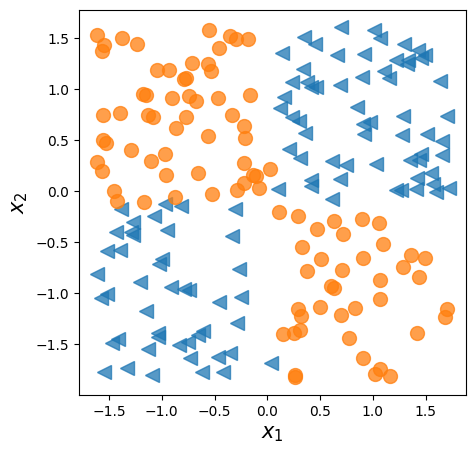

Размер обучающей выборки: 140
Размер тестовой выборки: 60
Распределение классов в train: [66 74]
Распределение классов в test: [28 32]


In [7]:
# 1. Генерация данных
np.random.seed(1)
x1 = np.random.uniform(low=-1, high=1, size=(200, 2))
y1 = np.where((x1[:, 1] * x1[:, 0]) >= 0.0, 1, 0)
# Стандартизация признаков
X_std1 = np.copy(x1)
X_std1[:, 0] = (x1[:, 0] - x1[:, 0].mean()) / x1[:, 0].std()
X_std1[:, 1] = (x1[:, 1] - x1[:, 1].mean()) / x1[:, 1].std()

# 2. Разделение на обучающую (70%) и тестовую (30%) выборки
x_train1, x_test1, y_train1, y_test1 = train_test_split(X_std1, y1, test_size=0.3, random_state=42, stratify=y1)

fig = plt.figure(figsize=(5, 5))
plt.plot(X_std1[y1==1, 0], X_std1[y1==1, 1], '<', alpha=0.75, markersize=10)
plt.plot(X_std1[y1==0, 0], X_std1[y1==0, 1], 'o', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

print(f"Размер обучающей выборки: {x_train1.shape[0]}")
print(f"Размер тестовой выборки: {x_test1.shape[0]}")
print(f"Распределение классов в train: {np.bincount(y_train1)}")
print(f"Распределение классов в test: {np.bincount(y_test1)}")

<h1 style="text-align:center;">Модели на основе PyTorch</h1>